In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import time
from pathlib import Path
from matplotlib.lines import Line2D

In [10]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC_0D
from model.coefficients import *
from config.initialize import *
from config.settings import *

## Sweep the 0D model across (RHC, P, T, I) conditions

For each operating point we run the lumped-parameter `PEMFC_0D` to steady state and snapshot the final-time states. The conditions match the existing `all_cond 50A stat.ipynb` and `all_cond 50A dyn.ipynb` notebooks for direct comparison.

In [11]:
pola_tests_sim = {}
load_points = [10, 20, 30, 35, 40, 45, 50]

# Reduce micro-scale resolution for the polar sweep -- Pt PSD details don't affect
# the steady-state polarization curve and we save a lot of wall-clock time.
params_0d = dict(parameters)
params_0d['n_group_pt'] = 10

for RHC in [0.5]:
    for P_des in [1.3, 1.4, 1.5]:
        for T_des in [323.15, 333.15, 343.15]:
            print(f"Simulating for RHC={RHC}, P_des={P_des} bar, T_des={T_des} K...")
            states_test = []
            for I_LOAD in load_points:
                op_0d = dict(operating_inputs)
                op_0d['Phi_c_des'] = RHC
                op_0d['Pa_des'] = P_des * 1e5
                op_0d['Pc_des'] = P_des * 1e5
                op_0d['Tfc'] = T_des
                op_0d['current_density'] = (lambda x, _I=I_LOAD: _I / params_0d['Aact'])

                model = PEMFC_0D(params_0d, op_0d)
                y0 = model.default_initial_state(params_0d, op_0d)
                # Tight atol because Wcp is O(1e-5 kg/s) and the BDF default
                # atol=1e-6 is coarse on that scale. sparsity=False since the
                # dense Jacobian is cheap at 31 states.
                info = model.solve(t_span=(0, 60), y0=y0, method='BDF',
                                   max_step=0.1, verbose=False, sparsity=False,
                                   atol=1e-8, rtol=1e-6)
                sol = info['sol']
                model._recovery(sol)

                states = {var_name: model.variables[var_name][-1]
                          for var_name in model.variable_names}
                for key in model.echem_traj:
                    if key != 't':
                        states[key] = model.echem_traj[key][-1]
                states_test.append(states)

            states_profile = {var: [s[var] for s in states_test]
                              for var in states_test[0].keys()}
            pola_tests_sim[f"RHC{RHC}_P{P_des}_T{T_des}"] = {"states": states_profile}

Simulating for RHC=0.5, P_des=1.3 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=343.15 K...


## Polarization curve

Same Ucell-vs-current presentation as the `stat` and `dyn` notebooks. Marker / colour / line-style are mapped via `plot_condition` from `config.settings` to (RHC, P, T).

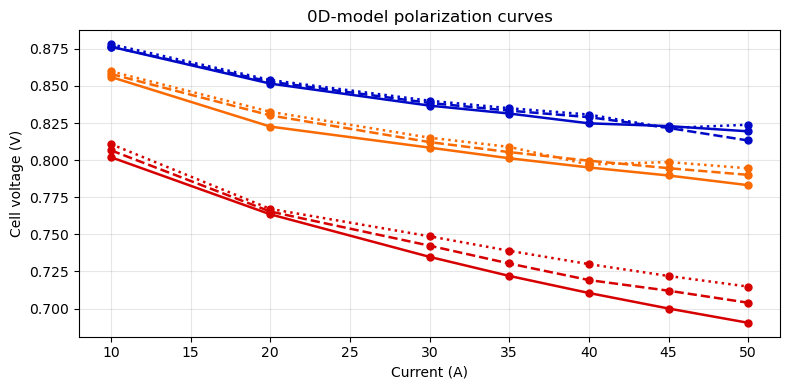

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for cond_key, value in pola_tests_sim.items():
    Ucell_curve = value["states"]["Ucell"]
    plot_condition(ax, load_points, Ucell_curve, cond_key, linewidth=1.8, markersize=5)
ax.set_title("0D-model polarization curves")
ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Polarization curve vs experimental data

Side-by-side with the `Polar_curves.xlsx` measurements -- same layout as the dynamic notebook.

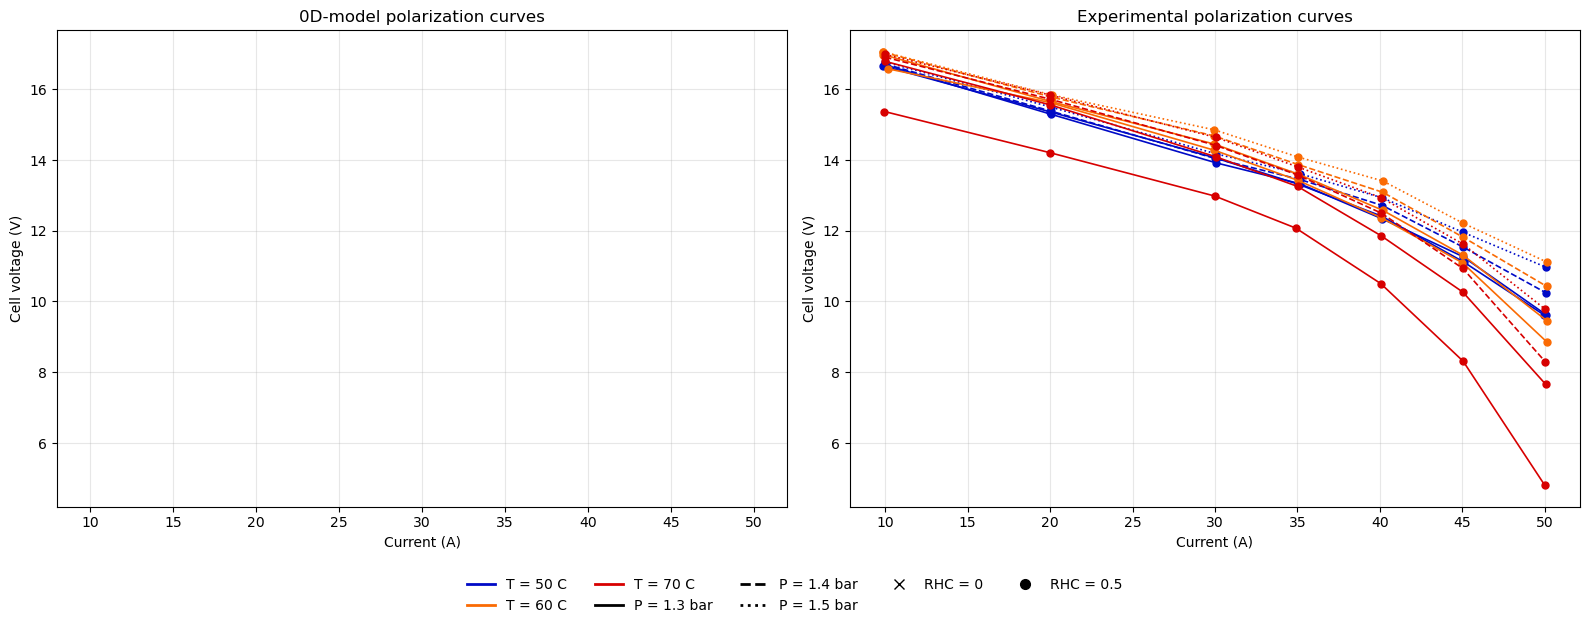

In [13]:
fig, ax = plt.subplots(figsize=(16, 6), nrows=1, ncols=2)

for cond_key, value in pola_tests_sim.items():
    Ucell_curve = value["states"]["Ucell"]
    plot_condition(ax[0], load_points, Ucell_curve, cond_key, linewidth=1.8, markersize=5)

exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
pola_testdata = {sname: pd.read_excel(exp_pola_data, sheet_name=sname)
                 for sname in exp_pola_data.sheet_names}

for name, data in pola_testdata.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    plot_condition(ax[1], i_values, v_values, name, linewidth=1.2, markersize=5)

legend_handles = []
for temperature, color in colormap_temp.items():
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2,
                                 label=f"T = {temperature:g} C"))
for pressure, linestyle in linemap_pressure.items():
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2,
                                 linestyle=linestyle, label=f"P = {pressure:g} bar"))
for humidity, marker in markermap_rh.items():
    legend_handles.append(Line2D([0], [0], color="black", linestyle="",
                                 marker=marker, markersize=7, label=f"RHC = {humidity}"))

ax[0].set_title("0D-model polarization curves")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Cell voltage (V)")
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim(ax[1].get_ylim())

ax[1].set_title("Experimental polarization curves")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Cell voltage (V)")
ax[1].grid(True, alpha=0.3)

fig.legend(legend_handles, [h.get_label() for h in legend_handles],
           loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## Voltage decomposition

Splits the cell voltage into Ueq / fdrop / eta_c / ohmic loss, just like the dynamic notebook's performance plot, but read straight from `echem_traj` since the 0D model already stores them.

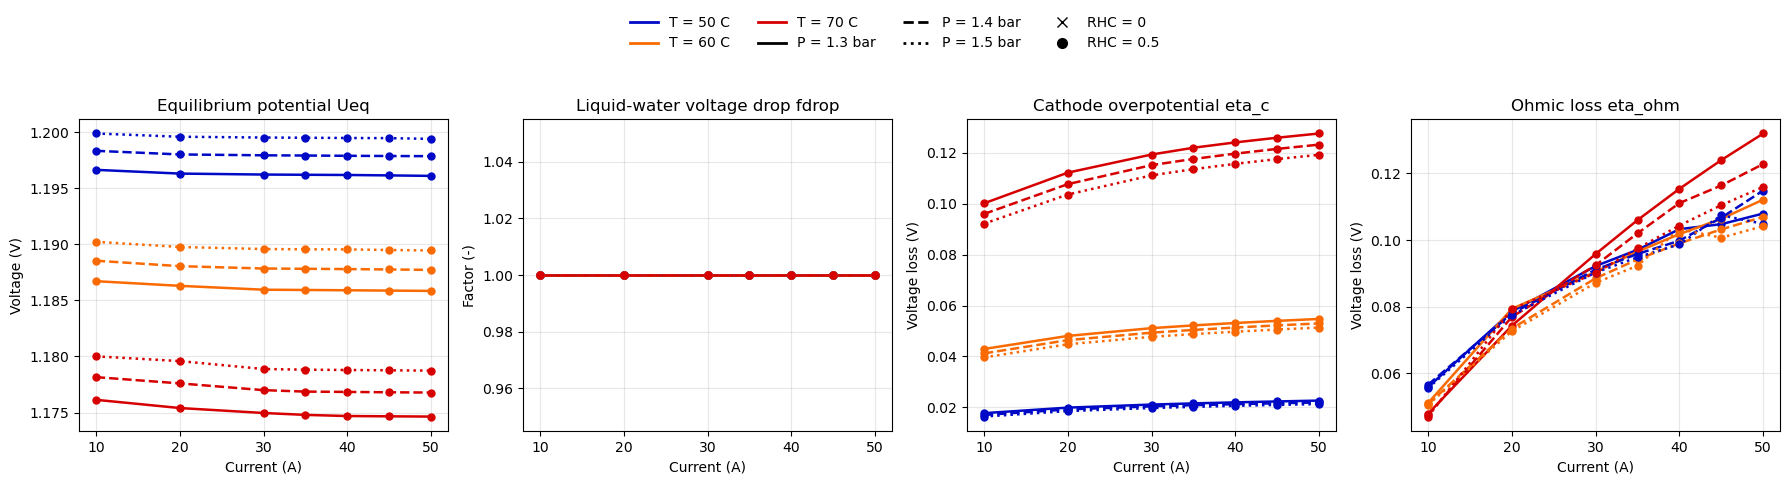

In [14]:
fig, ax = plt.subplots(figsize=(18, 4.5), nrows=1, ncols=4)

for cond_key, value in pola_tests_sim.items():
    Ueq      = np.array(value["states"]["Ueq"],      dtype=float)
    fdrop    = np.array(value["states"]["fdrop"],    dtype=float)
    eta_act  = np.array(value["states"]["eta_act"],  dtype=float)
    eta_conc = np.array(value["states"]["eta_conc"], dtype=float)
    Rmem     = np.array(value["states"]["Rmem"],     dtype=float)
    Rccl     = np.array(value["states"]["Rccl"],     dtype=float)
    Racl     = np.array(value["states"]["Racl"],     dtype=float)
    i_fc_arr = np.array(load_points, dtype=float) / params_0d["Aact"]
    eta_ohm  = (Rmem + Rccl + Racl + params_0d["Re"]) * i_fc_arr

    plot_condition(ax[0], load_points, Ueq,             cond_key, linewidth=1.8, markersize=5)
    plot_condition(ax[1], load_points, fdrop,           cond_key, linewidth=1.8, markersize=5)
    plot_condition(ax[2], load_points, eta_act+eta_conc,cond_key, linewidth=1.8, markersize=5)
    plot_condition(ax[3], load_points, eta_ohm,         cond_key, linewidth=1.8, markersize=5)

for axis, title, ylabel in zip(
    ax,
    ["Equilibrium potential Ueq", "Liquid-water voltage drop fdrop",
     "Cathode overpotential eta_c", "Ohmic loss eta_ohm"],
    ["Voltage (V)", "Factor (-)", "Voltage loss (V)", "Voltage loss (V)"]):
    axis.set_title(title)
    axis.set_xlabel("Current (A)")
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)

legend_handles = []
for temperature, color in colormap_temp.items():
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2,
                                 label=f"T = {temperature:g} C"))
for pressure, linestyle in linemap_pressure.items():
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2,
                                 linestyle=linestyle, label=f"P = {pressure:g} bar"))
for humidity, marker in markermap_rh.items():
    legend_handles.append(Line2D([0], [0], color="black", linestyle="",
                                 marker=marker, markersize=7, label=f"RHC = {humidity}"))
fig.legend(legend_handles, [h.get_label() for h in legend_handles],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

## Cathode BoP (0D-only output)

Pukrushpan's air-supply state — cathode supply manifold pressure `Pcsm`, return manifold pressure `Pcem` and compressor mass flow `Wcp` — plotted against current. No anode manifolds, no humidity states, no back-pressure-valve throttle area in this Pukrushpan-style model.

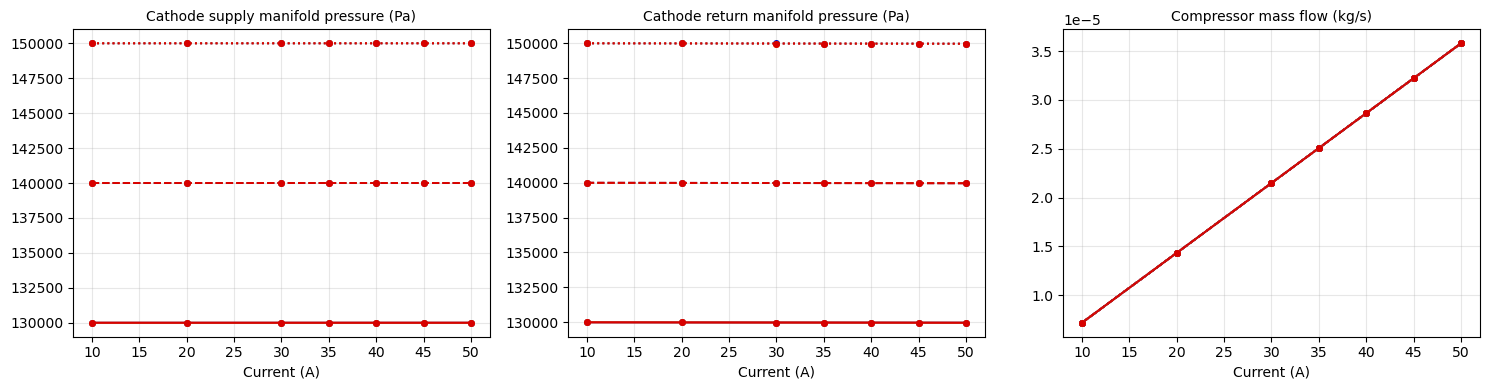

In [15]:
bop_vars = [
    ("Pcsm", "Cathode supply manifold pressure (Pa)"),
    ("Pcem", "Cathode return manifold pressure (Pa)"),
    ("Wcp",  "Compressor mass flow (kg/s)"),
]
fig, axes = plt.subplots(figsize=(15, 4), nrows=1, ncols=3)
for ax, (var, title) in zip(axes, bop_vars):
    for cond_key, value in pola_tests_sim.items():
        if var not in value["states"]:
            continue
        plot_condition(ax, load_points, value["states"][var], cond_key,
                       linewidth=1.4, markersize=4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Current (A)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell-state snapshots vs current

Lumped chamber concentrations and membrane state -- the 0D analogue of the 1D notebook's oxygen / vapour plots. No liquid-water saturation panel because this Pukrushpan-style 0D model does not track the liquid phase.

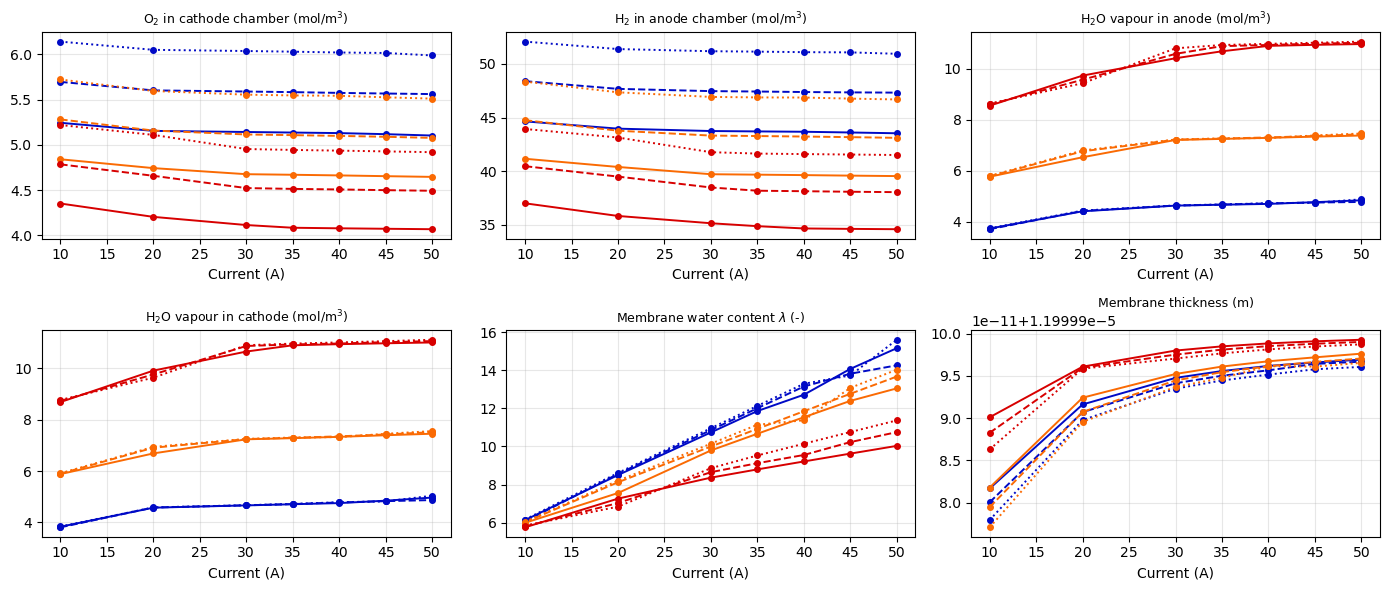

In [16]:
panels = [
    ("C_O2_c",     "O$_2$ in cathode chamber (mol/m$^3$)"),
    ("C_H2_a",     "H$_2$ in anode chamber (mol/m$^3$)"),
    ("C_v_a",      "H$_2$O vapour in anode (mol/m$^3$)"),
    ("C_v_c",      "H$_2$O vapour in cathode (mol/m$^3$)"),
    ("lambda_mem", r"Membrane water content $\lambda$ (-)"),
    ("Hmem",       "Membrane thickness (m)"),
]
fig, axes = plt.subplots(figsize=(14, 6), nrows=2, ncols=3)
for ax, (var, title) in zip(axes.flatten(), panels):
    for cond_key, value in pola_tests_sim.items():
        plot_condition(ax, load_points, value["states"][var], cond_key,
                       linewidth=1.4, markersize=4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Current (A)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()